In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2
from PIL import ImageDraw
from PIL import Image
import os
from matplotlib import cm

In [52]:
image_dir = 'yolov11_dataset/train/images/'
labels_dir = 'yolov11_dataset/train/labels/'

In [53]:
plots_annot_dir='plots/inference/'

In [54]:
os.makedirs(plots_annot_dir, exist_ok=True)
#os.makedirs(annot_dir_right, exist_ok=True)

In [55]:
#Loading images directory files
img_paths={}
def load_imgs_pths(txt_dir):
  for f in sorted(os.listdir(txt_dir)):
    img_paths[f.split('_jpg')[0]]=os.path.join(txt_dir+'/', f)

lbl_paths={}
def load_lbl_pths(txt_dir):
  for f in sorted(os.listdir(txt_dir)):
    lbl_paths[f.split('_jpg')[0]]=os.path.join(txt_dir+'/', f)

lbls_det={}
def load_bbox_dets():
  #Oriented Bounding boxes info
  lkeys = list(lbl_paths.keys())
  for lk in lkeys:
    file = open(lbl_paths[lk], "r")
    content = file.readlines()
    minil=[]
    for i in range(0, len(content)):
      minil.append(content[i].split()[1:])#No class or confidence #for samples I excluded the conf
    lbls_det[lk]=minil

""" msk_dic={}
def load_msks():
  for filename in sorted(os.listdir(masks_dir)):
    mask = Image.open(os.path.join(masks_dir, filename))
    fn_m = filename.split('_jpg')[0]
    mask = mask.convert("L")
    mask_array = np.array(mask).astype('float32')
    mask_array = mask_array / 255.0
    msk_dic[fn_m]=mask_array """

' msk_dic={}\ndef load_msks():\n  for filename in sorted(os.listdir(masks_dir)):\n    mask = Image.open(os.path.join(masks_dir, filename))\n    fn_m = filename.split(\'_jpg\')[0]\n    mask = mask.convert("L")\n    mask_array = np.array(mask).astype(\'float32\')\n    mask_array = mask_array / 255.0\n    msk_dic[fn_m]=mask_array '

In [56]:
#functions call
load_imgs_pths(image_dir)
load_lbl_pths(labels_dir)
load_bbox_dets()
#load_msks()

In [57]:
#Sorting function for easy data formatting
def sorting_custom(det_dict):
  try:
    parts = det_dict.split('_')
    #print(parts)
    fish_id = int(parts[1])  # Extract fish ID
    side = parts[-2]  # Extract side
    return fish_id, side
  except:
    print('oops')

In [58]:
keys = list(img_paths.keys())[-10:-1]

In [59]:
keys

['fish_46_S_day1_id-26_L_h',
 'fish_46_S_day1_id-26_R_h',
 'fish_47_S_day1_id-27_L_h',
 'fish_47_S_day1_id-27_R_h',
 'fish_48_S_day1_id-28_L_h',
 'fish_48_S_day1_id-28_R_h',
 'fish_49_S_day1_id-29_L_h',
 'fish_49_S_day1_id-29_R_h',
 'fish_50_S_day1_id-30_L_h']

In [60]:
values = list(img_paths.values())[-10:-1]

In [61]:
values

['yolov11_dataset/train/images//fish_46_S_day1_id-26_L_h_jpg.rf.f36d39c6e57b0c58ed6597a8c01b530d.jpg',
 'yolov11_dataset/train/images//fish_46_S_day1_id-26_R_h_jpg.rf.dd7ea6295a07541711c967e99a4a27e0.jpg',
 'yolov11_dataset/train/images//fish_47_S_day1_id-27_L_h_jpg.rf.e762ed65293dafd2ef8dba1aaef94e7f.jpg',
 'yolov11_dataset/train/images//fish_47_S_day1_id-27_R_h_jpg.rf.f0f876176a88b7be3cfd5cd478689847.jpg',
 'yolov11_dataset/train/images//fish_48_S_day1_id-28_L_h_jpg.rf.f755b8127dec715f1c5a154b39f23f5f.jpg',
 'yolov11_dataset/train/images//fish_48_S_day1_id-28_R_h_jpg.rf.ecd7b2f58a9704504083a96a9397f22e.jpg',
 'yolov11_dataset/train/images//fish_49_S_day1_id-29_L_h_jpg.rf.da0a4252a7dea1108903a09e3c093399.jpg',
 'yolov11_dataset/train/images//fish_49_S_day1_id-29_R_h_jpg.rf.fdb8628465a5f5e6124c719a86275210.jpg',
 'yolov11_dataset/train/images//fish_50_S_day1_id-30_L_h_jpg.rf.f0d1a759fe3a824fea0a8c19f8faa9fe.jpg']

In [62]:
subset_imgs = {}
for k,v in zip(keys, values):
    subset_imgs[k]=v

In [63]:
#Formatting the data
#sorted_fish_mean = dict(sorted(img_paths.items(), key=lambda x: sorting_custom(x[0])))
sorted_fish_mean = dict(sorted(subset_imgs.items(), key=lambda x: sorting_custom(x[0]))) #some samples to plot
print(sorted_fish_mean)

{'fish_46_S_day1_id-26_L_h': 'yolov11_dataset/train/images//fish_46_S_day1_id-26_L_h_jpg.rf.f36d39c6e57b0c58ed6597a8c01b530d.jpg', 'fish_46_S_day1_id-26_R_h': 'yolov11_dataset/train/images//fish_46_S_day1_id-26_R_h_jpg.rf.dd7ea6295a07541711c967e99a4a27e0.jpg', 'fish_47_S_day1_id-27_L_h': 'yolov11_dataset/train/images//fish_47_S_day1_id-27_L_h_jpg.rf.e762ed65293dafd2ef8dba1aaef94e7f.jpg', 'fish_47_S_day1_id-27_R_h': 'yolov11_dataset/train/images//fish_47_S_day1_id-27_R_h_jpg.rf.f0f876176a88b7be3cfd5cd478689847.jpg', 'fish_48_S_day1_id-28_L_h': 'yolov11_dataset/train/images//fish_48_S_day1_id-28_L_h_jpg.rf.f755b8127dec715f1c5a154b39f23f5f.jpg', 'fish_48_S_day1_id-28_R_h': 'yolov11_dataset/train/images//fish_48_S_day1_id-28_R_h_jpg.rf.ecd7b2f58a9704504083a96a9397f22e.jpg', 'fish_49_S_day1_id-29_L_h': 'yolov11_dataset/train/images//fish_49_S_day1_id-29_L_h_jpg.rf.da0a4252a7dea1108903a09e3c093399.jpg', 'fish_49_S_day1_id-29_R_h': 'yolov11_dataset/train/images//fish_49_S_day1_id-29_R_h_jpg.r

In [64]:
fnames = list(sorted_fish_mean.keys())
spots_dets={}
def plotting():
  for fn in fnames:
    img = Image.open(img_paths[fn])
    fig, ax = plt.subplots(1)
    ax.imshow(img)
    spots = 0
    for i in range(len(lbls_det[fn])):
      vertices = [float(x) for x in lbls_det[fn][i]]
      img_width, img_height = img.size

      #Convert fractional vertices to actual pixel coordinates
      pixel_vertices = [int(vertices[i] * img_width if i % 2 == 0 else vertices[i] * img_height) for i in range(len(vertices))]

      #Create a polygon patch from the vertices and add it to the plot
      polygon = patches.Polygon(xy=np.array(pixel_vertices).reshape(-1, 2),
                                closed=True,
                                edgecolor='green',
                                facecolor='none',
                                linewidth=1)
      ax.add_patch(polygon)
      ax.axis('off')  #Correct axis indexing and visibility handling
      spots+=1
    print('Total No. of Detected Spots: {0}'.format(spots))
    spots_dets[fn]=spots
    #Display the plot
    plt.title(fn)
    spots_leg = patches.Patch(color='green', label=f'Spots ({spots})')
    legend_handles = [spots_leg]
    plt.legend(handles=legend_handles, loc="upper left")
    plt.savefig(plots_annot_dir+fn+'.jpg', dpi=1200)
    plt.show()  #General display call (not tied to a specific axis)

Total No. of Detected Spots: 38


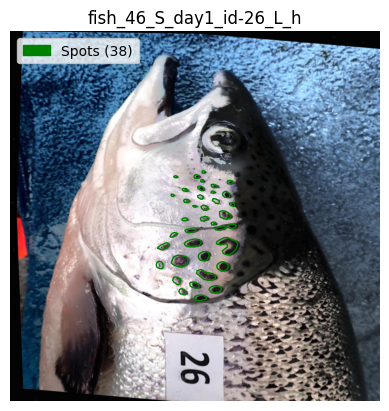

Total No. of Detected Spots: 48


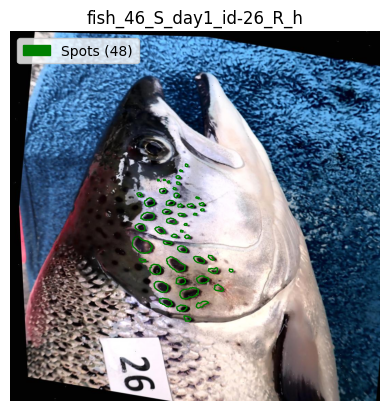

Total No. of Detected Spots: 31


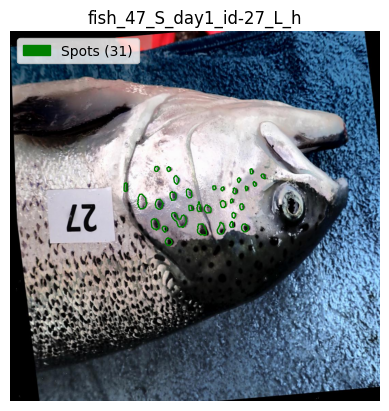

Total No. of Detected Spots: 43


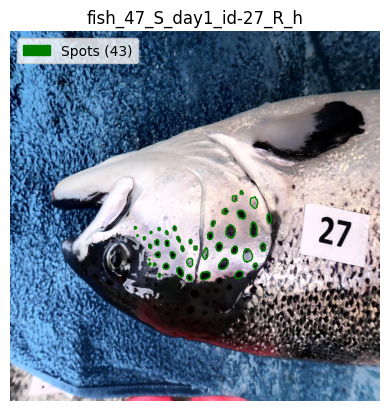

Total No. of Detected Spots: 27


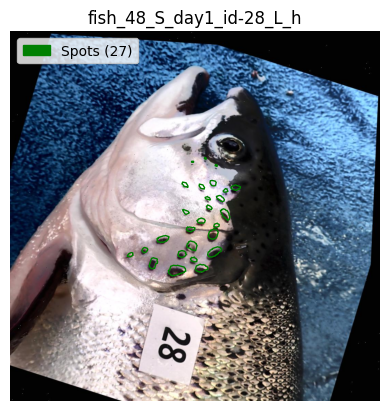

Total No. of Detected Spots: 28


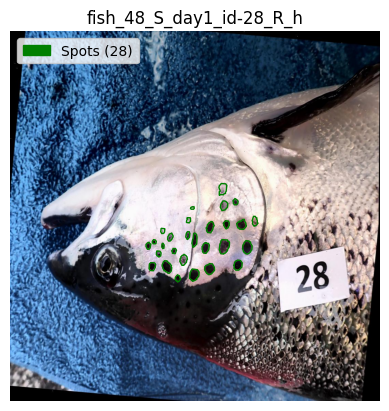

Total No. of Detected Spots: 25


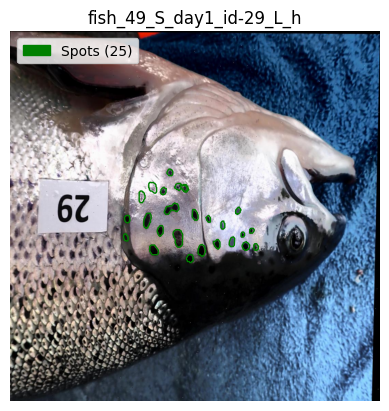

Total No. of Detected Spots: 32


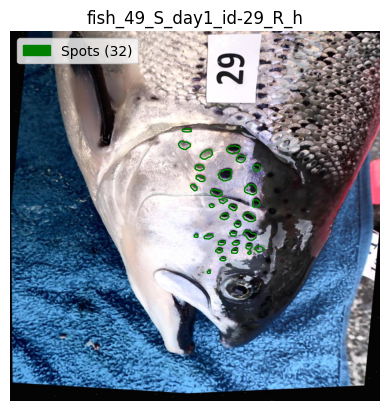

Total No. of Detected Spots: 44


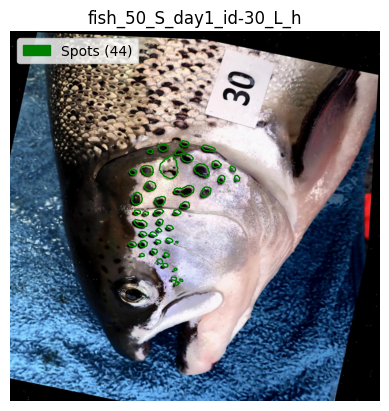

In [65]:
plotting()

In [44]:
""" def plotting_all_segs_left():
  for f_id,d1_id,d2_id in data_maps:
    #Image paths for Day 2 Left and Right Side images
    img_l_d2_p = f'fish_{f_id}_S_day2_id-{d2_id}_L_h'

    #Reading images 
    #Day 2 Left side 
    img = Image.open(img_paths[img_l_d2_p])
    fig, ax = plt.subplots(1, figsize=(30,30))
    ax.imshow(img)

    #For Left Side Day 2 
    #Day 1 plots - Pre Stress
    for i in range(len(lbls_det[f'fish_{f_id}_S_day1_id-{d1_id}_L_h'])):
      vertices = [float(x) for x in lbls_det[f'fish_{f_id}_S_day1_id-{d1_id}_L_h'][i]]
      img_width, img_height = img.size

      #Convert fractional vertices to actual pixel coordinates
      pixel_vertices = [int(vertices[i] * img_width if i % 2 == 0 else vertices[i] * img_height) for i in range(len(vertices))]

      #Create a polygon patch from the vertices and add it to the plot
      polygon = patches.Polygon(xy=np.array(pixel_vertices).reshape(-1, 2),
                                closed=True,
                                edgecolor='red',
                                facecolor='none',
                                linewidth=1)
      ax.add_patch(polygon)
      ax.axis('off')  #Correct axis indexing and visibility handling

    #Day 2 plots - Post Stress
    for i in range(len(lbls_det[f'fish_{f_id}_S_day2_id-{d2_id}_L_h'])):
      vertices = [float(x) for x in lbls_det[f'fish_{f_id}_S_day2_id-{d2_id}_L_h'][i]]
      img_width, img_height = img.size

      #Convert fractional vertices to actual pixel coordinates
      pixel_vertices = [int(vertices[i] * img_width if i % 2 == 0 else vertices[i] * img_height) for i in range(len(vertices))]

      #Create a polygon patch from the vertices and add it to the plot
      polygon = patches.Polygon(xy=np.array(pixel_vertices).reshape(-1, 2),
                                closed=True,
                                edgecolor='green',
                                facecolor='none',
                                linewidth=1)
      ax.add_patch(polygon)
      ax.axis('off')  #Correct axis indexing and visibility handling
    #Display the plot
    plt.title(f'fish_{f_id}_S_day2_id-{d2_id}_L_h')
    plt.savefig(annot_dir_left+f'fish_{f_id}_S_day2_id-{d2_id}_L_h'+'.jpg')
    plt.show()  #General display call (not tied to a specific axis) """

In [45]:
""" def plotting_all_segs_right():
  for f_id,d1_id,d2_id in data_maps:
    #Image paths for Day 2 Left and Right Side images
    img_r_d2_p = f'fish_{f_id}_S_day2_id-{d2_id}_R_h'

    #Reading images 
    #Day 2 Right Side 
    img = Image.open(img_paths[img_r_d2_p])
    fig, ax = plt.subplots(1, figsize=(30,30))
    ax.imshow(img)

    #For Right Side Day 2 
    #Day 1 plots - Pre Stress
    for i in range(len(lbls_det[f'fish_{f_id}_S_day1_id-{d1_id}_R_h'])):
      vertices = [float(x) for x in lbls_det[f'fish_{f_id}_S_day1_id-{d1_id}_R_h'][i]]
      img_width, img_height = img.size

      #Convert fractional vertices to actual pixel coordinates
      pixel_vertices = [int(vertices[i] * img_width if i % 2 == 0 else vertices[i] * img_height) for i in range(len(vertices))]

      #Create a polygon patch from the vertices and add it to the plot
      polygon = patches.Polygon(xy=np.array(pixel_vertices).reshape(-1, 2),
                                closed=True,
                                edgecolor='red',
                                facecolor='none',
                                linewidth=1)
      ax.add_patch(polygon)
      ax.axis('off')  #Correct axis indexing and visibility handling

    #Day 2 plots - Post Stress
    for i in range(len(lbls_det[f'fish_{f_id}_S_day2_id-{d2_id}_R_h'])):
      vertices = [float(x) for x in lbls_det[f'fish_{f_id}_S_day2_id-{d2_id}_R_h'][i]]
      img_width, img_height = img.size

      #Convert fractional vertices to actual pixel coordinates
      pixel_vertices = [int(vertices[i] * img_width if i % 2 == 0 else vertices[i] * img_height) for i in range(len(vertices))]

      #Create a polygon patch from the vertices and add it to the plot
      polygon = patches.Polygon(xy=np.array(pixel_vertices).reshape(-1, 2),
                                closed=True,
                                edgecolor='green',
                                facecolor='none',
                                linewidth=1)
      ax.add_patch(polygon)
      ax.axis('off')  #Correct axis indexing and visibility handling
    #Display the plot
    plt.title(f'fish_{f_id}_S_day2_id-{d2_id}_R_h')
    plt.savefig(annot_dir_right+f'fish_{f_id}_S_day2_id-{d2_id}_R_h'+'.jpg')
    plt.show()  #General display call (not tied to a specific axis) """

In [ ]:
#plotting_all_segs_left()

In [ ]:
#plotting_all_segs_right()

In [ ]:
#plotting()

In [ ]:
#spots_dets

{'fish_10_S_day1_id-51_L_h': 54,
 'fish_10_S_day2_id-131_L_h': 58,
 'fish_10_S_day1_id-51_R_h': 50,
 'fish_10_S_day2_id-131_R_h': 53,
 'fish_11_S_day1_id-63_L_h': 32,
 'fish_11_S_day2_id-132_L_h': 29,
 'fish_11_S_day1_id-63_R_h': 22,
 'fish_11_S_day2_id-132_R_h': 23,
 'fish_12_S_day1_id-82_L_h': 21,
 'fish_12_S_day2_id-134_L_h': 22,
 'fish_12_S_day1_id-82_R_h': 27,
 'fish_12_S_day2_id-134_R_h': 27,
 'fish_13_S_day1_id-99_L_h': 17,
 'fish_13_S_day2_id-135_L_h': 14,
 'fish_13_S_day1_id-99_R_h': 14,
 'fish_13_S_day2_id-135_R_h': 12,
 'fish_14_S_day1_id-61_L_h': 31,
 'fish_14_S_day2_id-138_L_h': 31,
 'fish_14_S_day1_id-61_R_h': 34,
 'fish_14_S_day2_id-138_R_h': 35,
 'fish_15_S_day1_id-79_L_h': 25,
 'fish_15_S_day2_id-146_L_h': 34,
 'fish_15_S_day1_id-79_R_h': 37,
 'fish_15_S_day2_id-146_R_h': 38,
 'fish_16_S_day1_id-52_L_h': 33,
 'fish_16_S_day2_id-148_L_h': 32,
 'fish_16_S_day1_id-52_R_h': 41,
 'fish_16_S_day2_id-148_R_h': 40,
 'fish_17_S_day1_id-121_L_h': 22,
 'fish_17_S_day2_id-150_L_h'

In [ ]:
fnames = list(sorted_fish_mean.keys())
def plotting():
  for fn in fnames:
      img = Image.open(img_paths[fn])
      fig, axs = plt.subplots(1, 3, figsize=(10, 5))
      fig.subplots_adjust(hspace=0.4, wspace=0.7)

      axs[0].imshow(img, cmap='gray')
      axs[0].set_title('Original Image')

      axs[1].imshow(msk_dic[fn], cmap='gray')
      axs[1].set_title('Mask')

      spots = 0
      for i in range(len(lbls_det[fn+'_roi'])):
          vertices = [float(x) for x in lbls_det[fn+'_roi'][i]]
          img_width, img_height = img.size

          #Convert fractional vertices to actual pixel coordinates
          pixel_vertices = [int(vertices[i] * img_width if i % 2 == 0 else vertices[i] * img_height) for i in range(len(vertices))]

          #Create a polygon patch from the vertices and add it to the plot
          polygon = patches.Polygon(xy=np.array(pixel_vertices).reshape(-1, 2),
                                    closed=True,
                                    edgecolor='red',
                                    facecolor='none',
                                    linewidth=1)
          axs[2].add_patch(polygon)
          axs[2].axis('off')
          spots+=1
      axs[2].imshow(img, cmap='gray')
      axs[2].set_title('Spots')
      print(f'----------------------------------------{fn}----------------------------------------')
      print('Total No. of Detected Spots: {0}'.format(spots))
      plt.show()

In [ ]:
plotting() #based on new rois - Images Pack (original, masks, spots)

In [ ]:
fnames = list(sorted_fish_mean.keys())
for fn in fnames:
    msk = msk_dic[fn]
    fig, ax = plt.subplots(1)
    ax.imshow(msk, cmap='gray')
    print(f'----------------------------------------{fn}----------------------------------------')
    plt.savefig(plots_msk_dir+fn+'_msk.jpg')
    plt.show()

In [1]:
import torch

Tensor x: tensor([ 1.,  3.,  6., 10.])
Tensor y: tensor([ 2.,  7.,  9., 13.])
join tensors:
t:tensor([[ 1.,  3.,  6., 10.],
        [ 2.,  7.,  9., 13.]])


In [16]:
# creating tensors 
x = torch.tensor([1.,3.,6.,10., 11.]) 
y = torch.tensor([2.,7.,9.,13.]) 
  
# printing above created tensors 
print("Tensor x:", x) 
print("Tensor y:", y) 

padding = x.shape[-1] - y.shape[-1]

y_padded = torch.nn.functional.pad(y, (0, padding))

concatenated = torch.cat((x,y_padded), 0)
  

Tensor x: tensor([ 1.,  3.,  6., 10., 11.])
Tensor y: tensor([ 2.,  7.,  9., 13.])


In [17]:
concatenated

tensor([ 1.,  3.,  6., 10., 11.,  2.,  7.,  9., 13.,  0.])

In [12]:
print(concatenated.shape)

torch.Size([2, 5])


In [ ]:
# join above tensor using "torch.stack()" 
print("join tensors:") 
t = torch.stack((x,y), dim=0) 
print(f't:{t}')

In [11]:
a = [1,2,3,4,5]
b = [1,2,3,4,5,6]
c = [1,2,3]
    

In [13]:
d = a+b+c

In [14]:
d

[1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 6, 1, 2, 3]

In [12]:
a.extend(b,c)

TypeError: list.extend() takes exactly one argument (2 given)

In [ ]:
a.extend(c)

[1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 6]

In [9]:
a.extend(c)

In [10]:
a

[1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 6, 1, 2, 3]